In [1]:
from datetime import datetime

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.dates as mdates

%matplotlib widget

In [2]:
d = np.load("rfi_waterfall.npz")
ts = d["times"]
freqs = d["freqs"]
data = d["data"]

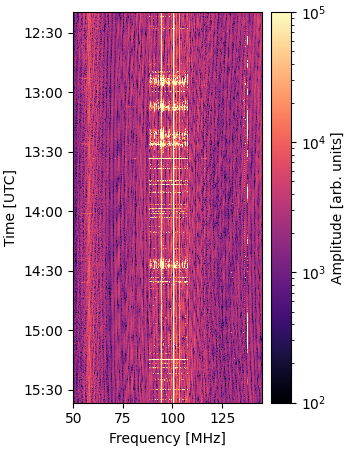

In [5]:
plt.figure(figsize=(3.5, 4.5), constrained_layout=True)
tmin = datetime.fromtimestamp(ts[0] + 6*3600)  # to UTC
tmax = datetime.fromtimestamp(ts[-1] + 6*3600)  # to UTC
extent = [freqs.min()/1e6, freqs.max()/1e6, tmax, tmin]
plt.gca().yaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.xlim(50, 145)
plt.imshow(np.abs(data), norm=colors.LogNorm(1e2, 1e5), aspect="auto", extent=extent, interpolation="none", cmap="magma")
plt.xlabel("Frequency [MHz]")
plt.ylabel("Time [UTC]")
#plt.title("Marjum Pass, July 21, 2024")
plt.colorbar(label="Amplitude [arb. units]")
#plt.savefig("rfi_waterfall.pdf", bbox_inches="tight")
plt.show()